# Direct-mDST four-momentum validation

## tl;dr

The default executed sample contains **100 real MC16ri_run2 events**, **2,169
truth-comparable retained nodes**, and **1,390 matched final-state particles**.
All 100 event trees pass parent/daughter and four-vector closure checks.

For matched final-state particles, the default sample has mean
$\Delta E = E_{computed}-E_{MC} = -0.078$ GeV with RMSE $0.340$ GeV.
At event level, summing the same matched final-state population gives mean
$\Delta E=-1.089$ GeV and mean $\Delta m=-1.121$ GeV/$c^2$.

Unmatched reconstructed objects are intentionally excluded from MC residuals:
they are valid production records, but they do not have a defensible
particle-by-particle truth comparator.

## Context & Methods

This notebook validates the `direct-mdst-tree-v1` output produced by
`scripts/preprocess_mdst.py`. Reconstructed/computed four-vectors and diagnostic
MC four-vectors remain separate throughout.

### Key Assumptions

- A **truth-comparable node** has diagnostic MC four-momentum and is not a
  copied node.
- A **matched final-state particle** is a truth-comparable leaf with a
  reconstructed object ID.
- Particle residuals use matched final-state particles only.
- Event totals sum those same matched final-state particles within each event,
  so reconstructed and MC totals use identical membership.
- Composite computed four-momenta are recursive daughter sums. They appear in
  the all-node distribution comparison, but not in final-state totals.
- Invariant mass is recomputed as
  $m=\sqrt{\max(E^2-p_x^2-p_y^2-p_z^2, 0)}$.
- Histogram axes show the central 99% to keep bulk structure readable; tables
  report untrimmed residual metrics.

## Data

### 1. Load the verified preprocessing output

In [1]:
from pathlib import Path
import json
import os

import awkward as ak
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

INPUT_PATH = Path(
    os.environ.get(
        "HYPERTAGGING_PREPROCESS_OUTPUT",
        '/data/dust/user/boyangyu/hypertagging/preprocess_mc16ri_run2_100.parquet',
    )
)
assert INPUT_PATH.exists(), f"Missing preprocessing output: {INPUT_PATH}"

payload = ak.to_list(ak.from_parquet(INPUT_PATH))[0]
assert payload["schema_version"] == "direct-mdst-tree-v1"
events = payload["events"]
production_summary = json.loads(payload["summary_json"])

plt.rcParams.update({
    "figure.figsize": (12, 8),
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.22,
    "font.size": 10,
})

COLORS = {
    "computed": "#2C6EBA",
    "mc": "#D4A72C",
    "residual": "#D97706",
    "zero": "#374151",
}

print(f"Input: {INPUT_PATH}")
print(f"Schema: {payload['schema_version']}")
print(f"Events: {len(events)}")

Input: /data/dust/user/boyangyu/hypertagging/preprocess_mc16ri_run2_100.parquet
Schema: direct-mdst-tree-v1
Events: 100


### 2. Build comparable node and final-state tables

In [2]:
def invariant_mass(energy, px, py, pz):
    mass_squared = np.asarray(energy) ** 2 - np.asarray(px) ** 2 - np.asarray(py) ** 2 - np.asarray(pz) ** 2
    return np.sqrt(np.clip(mass_squared, 0.0, None))


node_rows = []
max_parent_closure = 0.0
for event in events:
    nodes_by_id = {int(node["node_id"]): node for node in event["nodes"]}
    for node in event["nodes"]:
        daughters = node["daughter_ids"]
        if daughters:
            for field in ("energy", "px", "py", "pz"):
                daughter_sum = sum(float(nodes_by_id[child][field]) for child in daughters)
                max_parent_closure = max(max_parent_closure, abs(float(node[field]) - daughter_sum))

        if node["mc_energy"] is None or int(node["copied_from"]) != -1:
            continue
        node_rows.append(
            {
                "event_id": int(event["event_id"]),
                "node_id": int(node["node_id"]),
                "pdg": int(node["pdg"]),
                "is_leaf": not daughters,
                "has_reco": bool(node["reco_id"]),
                "E": float(node["energy"]),
                "px": float(node["px"]),
                "py": float(node["py"]),
                "pz": float(node["pz"]),
                "mc_E": float(node["mc_energy"]),
                "mc_px": float(node["mc_px"]),
                "mc_py": float(node["mc_py"]),
                "mc_pz": float(node["mc_pz"]),
            }
        )

comparable_nodes = pd.DataFrame(node_rows)
comparable_nodes["mass"] = invariant_mass(
    comparable_nodes["E"], comparable_nodes["px"], comparable_nodes["py"], comparable_nodes["pz"]
)
comparable_nodes["mc_mass"] = invariant_mass(
    comparable_nodes["mc_E"],
    comparable_nodes["mc_px"],
    comparable_nodes["mc_py"],
    comparable_nodes["mc_pz"],
)

matched_particles = comparable_nodes.query("is_leaf and has_reco").copy()
components = ["E", "px", "py", "pz", "mass"]
for component in components:
    matched_particles[f"delta_{component}"] = (
        matched_particles[component] - matched_particles[f"mc_{component}"]
    )

event_totals = matched_particles.groupby("event_id", as_index=True)[
    ["E", "px", "py", "pz", "mc_E", "mc_px", "mc_py", "mc_pz"]
].sum()
event_totals["mass"] = invariant_mass(
    event_totals["E"], event_totals["px"], event_totals["py"], event_totals["pz"]
)
event_totals["mc_mass"] = invariant_mass(
    event_totals["mc_E"], event_totals["mc_px"], event_totals["mc_py"], event_totals["mc_pz"]
)
for component in components:
    event_totals[f"delta_{component}"] = event_totals[component] - event_totals[f"mc_{component}"]

assert len(comparable_nodes) > 0
assert len(matched_particles) > 0
assert np.isfinite(comparable_nodes.select_dtypes("number").to_numpy()).all()
assert max_parent_closure < 1e-8

pd.DataFrame(
    {
        "value": [
            len(events),
            len(comparable_nodes),
            len(matched_particles),
            len(event_totals),
            production_summary.get("unmatched_reco", 0),
            max_parent_closure,
        ]
    },
    index=[
        "input events",
        "truth-comparable retained nodes",
        "matched final-state particles",
        "events with matched particles",
        "unmatched reco objects excluded from residuals",
        "maximum parent p4 closure error",
    ],
)

,value
input events,100.0
truth-comparable retained nodes,2169.0
matched final-state particles,1390.0
events with matched particles,100.0
unmatched reco objects excluded from residuals,2529.0
maximum parent p4 closure error,0.0


## Results

### 3. Computed and MC component distributions for all comparable nodes

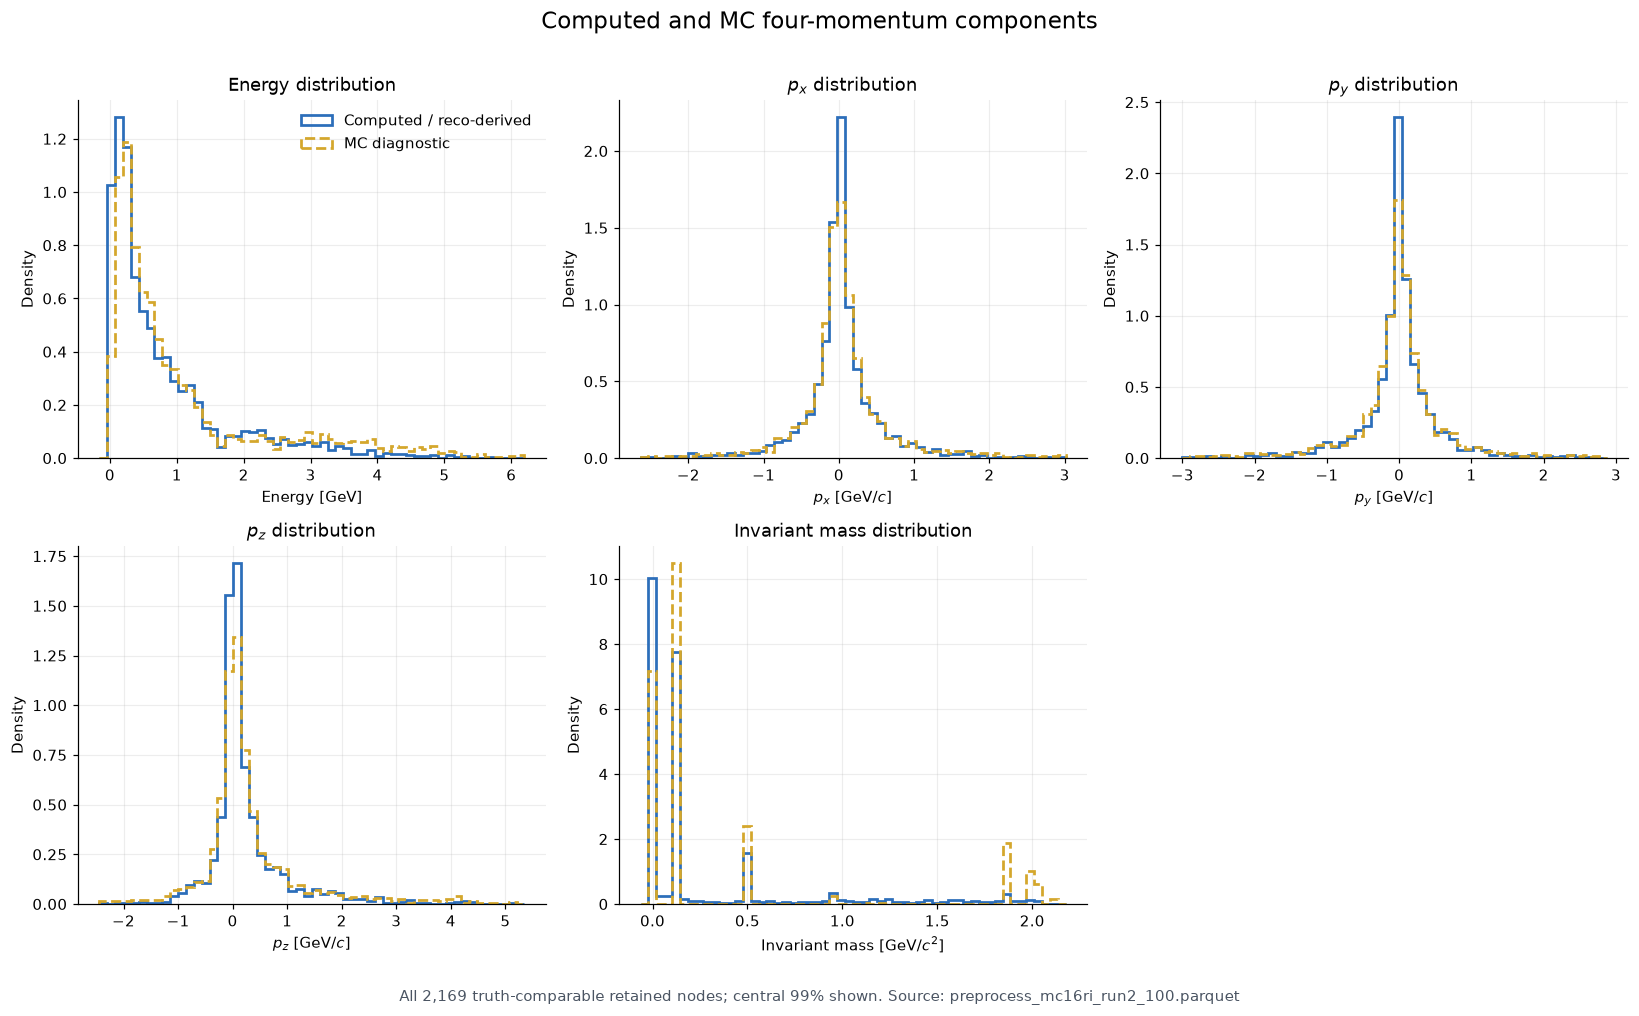

In [3]:
component_labels = {
    "E": "Energy [GeV]",
    "px": "$p_x$ [GeV/$c$]",
    "py": "$p_y$ [GeV/$c$]",
    "pz": "$p_z$ [GeV/$c$]",
    "mass": "Invariant mass [GeV/$c^2$]",
}


def central_limits(*series, lower=0.005, upper=0.995, symmetric=False):
    values = np.concatenate([np.asarray(item, dtype=float) for item in series])
    values = values[np.isfinite(values)]
    if symmetric:
        bound = np.quantile(np.abs(values), upper)
        return (-bound, bound) if bound > 0 else (-1.0, 1.0)
    low, high = np.quantile(values, [lower, upper])
    if not high > low:
        return low - 0.5, high + 0.5
    padding = 0.03 * (high - low)
    return low - padding, high + padding


fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for axis, component in zip(axes.flat, components):
    computed = comparable_nodes[component]
    mc = comparable_nodes[f"mc_{component}"]
    low, high = central_limits(computed, mc)
    bins = np.linspace(low, high, 55)
    axis.hist(
        computed,
        bins=bins,
        density=True,
        histtype="step",
        linewidth=1.8,
        color=COLORS["computed"],
        label="Computed / reco-derived",
    )
    axis.hist(
        mc,
        bins=bins,
        density=True,
        histtype="step",
        linewidth=1.8,
        linestyle="--",
        color=COLORS["mc"],
        label="MC diagnostic",
    )
    axis.set_title(f"{component_labels[component].split(' [')[0]} distribution")
    axis.set_xlabel(component_labels[component])
    axis.set_ylabel("Density")
axes.flat[0].legend(frameon=False)
axes.flat[-1].axis("off")
fig.suptitle("Computed and MC four-momentum components", fontsize=15, y=1.01)
fig.text(
    0.5,
    0.01,
    f"All {len(comparable_nodes):,} truth-comparable retained nodes; central 99% shown. Source: {INPUT_PATH.name}",
    ha="center",
    color="#4B5563",
)
fig.tight_layout(rect=(0, 0.04, 1, 1))
plt.show()

### 4. Particle-by-particle component differences

In [4]:
def residual_metrics(frame, prefix):
    records = []
    for component in components:
        values = frame[f"delta_{component}"].to_numpy()
        records.append(
            {
                "scope": prefix,
                "component": component,
                "count": len(values),
                "mean": np.mean(values),
                "median": np.median(values),
                "RMSE": np.sqrt(np.mean(values**2)),
                "95% |difference|": np.quantile(np.abs(values), 0.95),
            }
        )
    return pd.DataFrame(records)


particle_metrics = residual_metrics(matched_particles, "particle")
particle_metrics.style.format(
    {"mean": "{:.4f}", "median": "{:.4f}", "RMSE": "{:.4f}", "95% |difference|": "{:.4f}"}
)

,scope,component,count,mean,median,RMSE,95% |difference|
0,particle,E,1390,-0.0784,-0.0006,0.3396,0.6958
1,particle,px,1390,-0.0037,-0.0001,0.1302,0.1467
2,particle,py,1390,-0.0020,0.0001,0.1390,0.2088
3,particle,pz,1390,-0.0136,-0.0000,0.2880,0.4896
4,particle,mass,1390,-0.0204,0.0000,0.0978,0.1396


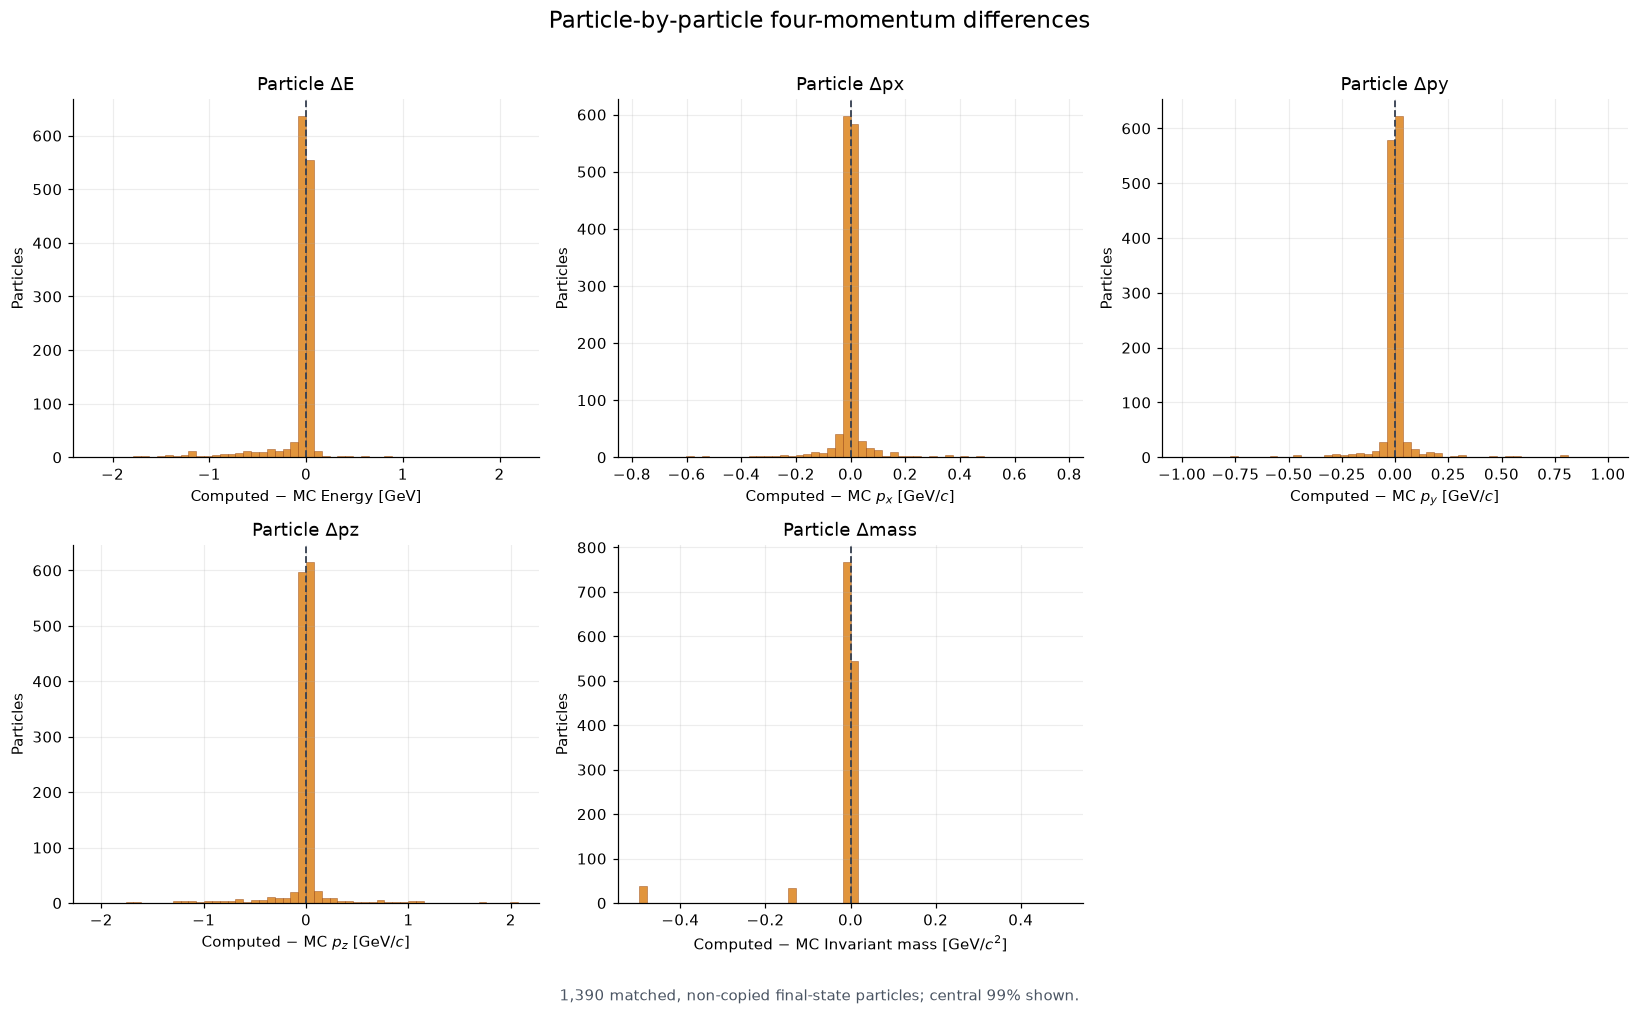

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for axis, component in zip(axes.flat, components):
    residual = matched_particles[f"delta_{component}"]
    low, high = central_limits(residual, symmetric=True)
    axis.hist(
        residual,
        bins=np.linspace(low, high, 55),
        color=COLORS["residual"],
        alpha=0.78,
        edgecolor="#92400E",
        linewidth=0.35,
    )
    axis.axvline(0.0, color=COLORS["zero"], linestyle="--", linewidth=1.2)
    axis.set_title(f"Particle $\Delta${component}")
    axis.set_xlabel(f"Computed − MC {component_labels[component]}")
    axis.set_ylabel("Particles")
axes.flat[-1].axis("off")
fig.suptitle("Particle-by-particle four-momentum differences", fontsize=15, y=1.01)
fig.text(
    0.5,
    0.01,
    f"{len(matched_particles):,} matched, non-copied final-state particles; central 99% shown.",
    ha="center",
    color="#4B5563",
)
fig.tight_layout(rect=(0, 0.04, 1, 1))
plt.show()

### 5. Event-by-event total component differences

In [6]:
event_metrics = residual_metrics(event_totals, "event")
event_metrics.style.format(
    {"mean": "{:.4f}", "median": "{:.4f}", "RMSE": "{:.4f}", "95% |difference|": "{:.4f}"}
)

,scope,component,count,mean,median,RMSE,95% |difference|
0,event,E,100,-1.0895,-0.8682,1.6325,3.5134
1,event,px,100,-0.0510,0.0029,0.4925,0.9151
2,event,py,100,-0.0277,-0.0167,0.4486,0.9737
3,event,pz,100,-0.1893,-0.0244,0.9492,2.2720
4,event,mass,100,-1.1213,-0.8672,1.7014,3.6890


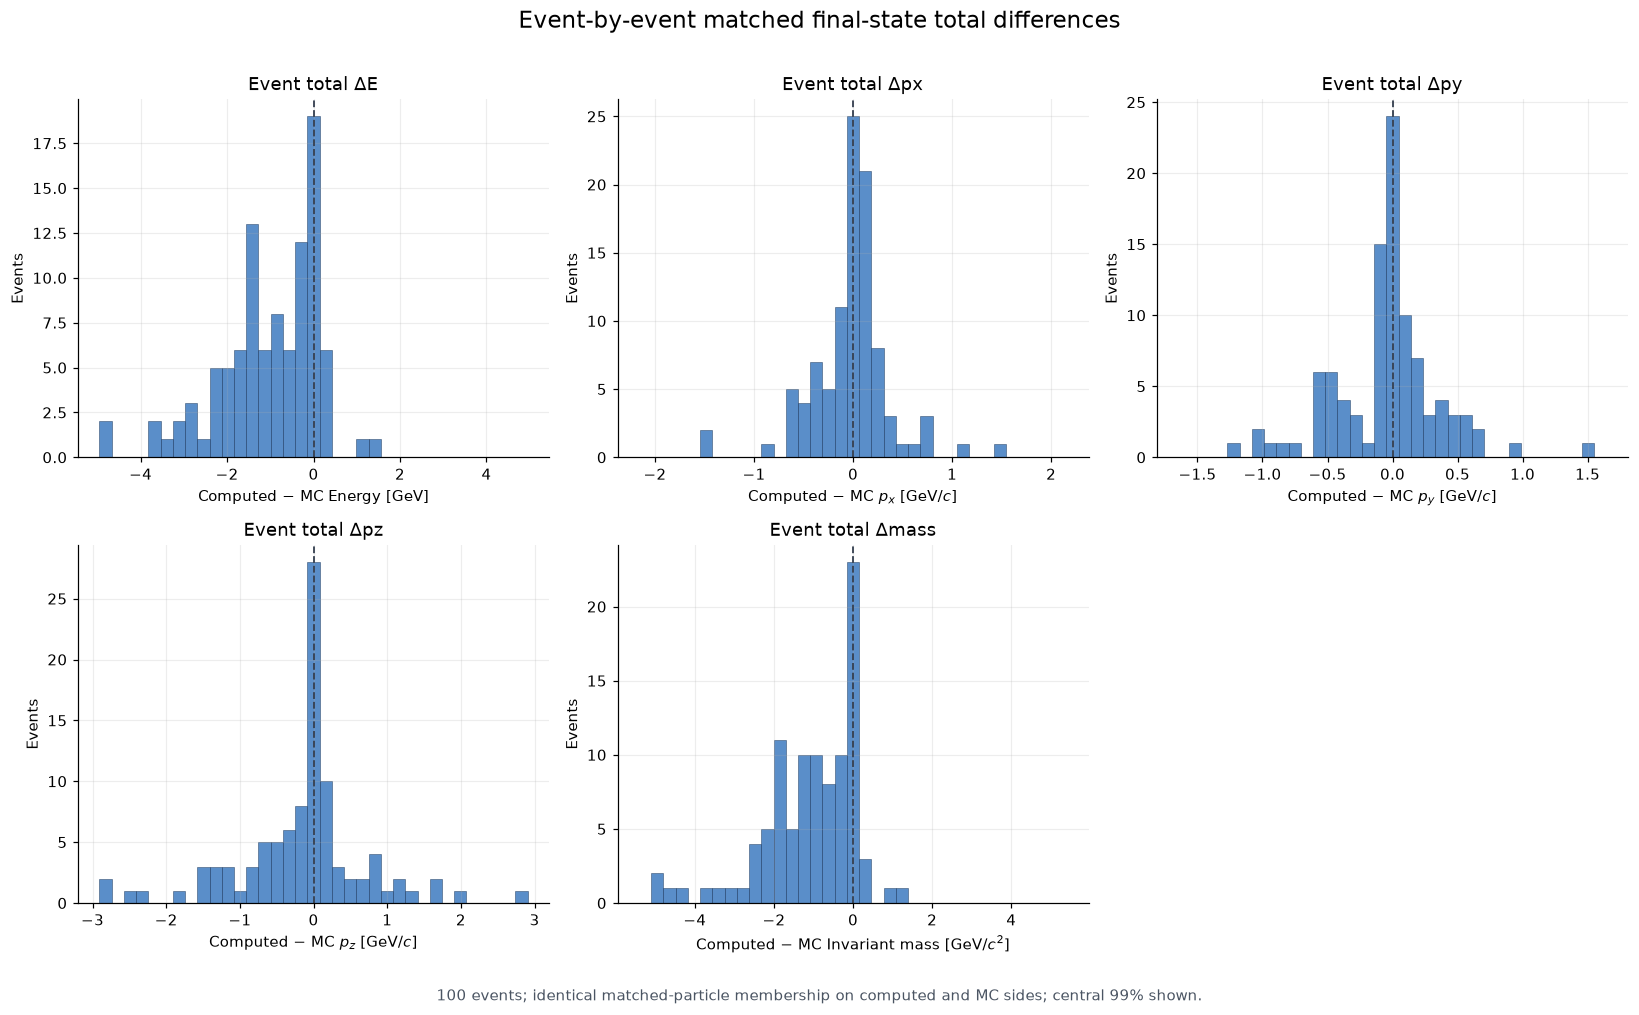

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for axis, component in zip(axes.flat, components):
    residual = event_totals[f"delta_{component}"]
    low, high = central_limits(residual, symmetric=True)
    axis.hist(
        residual,
        bins=np.linspace(low, high, 36),
        color=COLORS["computed"],
        alpha=0.78,
        edgecolor="#1E3A5F",
        linewidth=0.4,
    )
    axis.axvline(0.0, color=COLORS["zero"], linestyle="--", linewidth=1.2)
    axis.set_title(f"Event total $\Delta${component}")
    axis.set_xlabel(f"Computed − MC {component_labels[component]}")
    axis.set_ylabel("Events")
axes.flat[-1].axis("off")
fig.suptitle("Event-by-event matched final-state total differences", fontsize=15, y=1.01)
fig.text(
    0.5,
    0.01,
    f"{len(event_totals):,} events; identical matched-particle membership on computed and MC sides; central 99% shown.",
    ha="center",
    color="#4B5563",
)
fig.tight_layout(rect=(0, 0.04, 1, 1))
plt.show()

## Takeaways

In [8]:
summary_table = pd.concat([particle_metrics, event_metrics], ignore_index=True)
particle_energy = summary_table.query("scope == 'particle' and component == 'E'").iloc[0]
event_energy = summary_table.query("scope == 'event' and component == 'E'").iloc[0]
event_mass = summary_table.query("scope == 'event' and component == 'mass'").iloc[0]

print(
    f"• Structural QA: {len(events)} event trees passed; maximum parent p4 closure error "
    f"was {max_parent_closure:.3g}."
)
print(
    f"• Particle level: {len(matched_particles):,} matched leaves have mean ΔE "
    f"{particle_energy['mean']:.3f} GeV and energy RMSE {particle_energy['RMSE']:.3f} GeV."
)
print(
    f"• Event level: mean ΔE is {event_energy['mean']:.3f} GeV and mean Δmass is "
    f"{event_mass['mean']:.3f} GeV/c² for the matched final-state subset."
)
print(
    "• Interpretation boundary: unmatched reconstructed objects remain in the production file "
    "but are excluded here because a truth residual would be undefined."
)

• Structural QA: 100 event trees passed; maximum parent p4 closure error was 0.
• Particle level: 1,390 matched leaves have mean ΔE -0.078 GeV and energy RMSE 0.340 GeV.
• Event level: mean ΔE is -1.089 GeV and mean Δmass is -1.121 GeV/c² for the matched final-state subset.
• Interpretation boundary: unmatched reconstructed objects remain in the production file but are excluded here because a truth residual would be undefined.


The negative event-level energy and mass differences are descriptive validation
results, not by themselves evidence of a preprocessing error. They can include
detector response, reconstruction inefficiency, acceptance, and MC-matching
selection effects. A physics-performance conclusion would require explicit
particle selections and efficiency/purity studies beyond this preprocessing audit.